# Preprocessing

In [1]:
import pandas as pd

data = pd.read_csv("players_data-2024_2025.csv")
data.head()

,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,Att (GK),Thr,Launch%,AvgLen,Opp,Stp,Stp%,#OPA,#OPA/90,AvgDist
0,1,Max Aarons,eng ENG,DF,Bournemouth,eng Premier League,24.0,2000.0,3,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Max Aarons,eng ENG,"DF,MF",Valencia,es La Liga,24.0,2000.0,4,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Rodrigo Abajas,es ESP,DF,Valencia,es La Liga,21.0,2003.0,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,James Abankwah,ie IRL,"DF,MF",Udinese,it Serie A,20.0,2004.0,6,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,Keyliane Abdallah,fr FRA,FW,Marseille,fr Ligue 1,18.0,2006.0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
cols_interest = [
    "Player",
    "MP",
    "Starts",
    "Min",
    "Gls",
    "Ast",
    "xG",
    "xA",
    "PrgC",
    "PrgP",
    "Sh",
    "SoT",
    "Cmp",
    "Att",
    "TotDist",
    "PrgDist",
    "KP",
    "TO",
    "Touches",
    "Succ",
    "Tkld",
    "Compl",
    "+/-"
]

In [3]:
prem_data = data[data["Comp"] == "eng Premier League"]

fwds_data = prem_data[prem_data["Pos"].str.contains("FW")]
fwds_data = fwds_data[cols_interest]

### Duplicate Player Entries

In [4]:
fwds_data[fwds_data["Player"].duplicated()]

,Player,MP,Starts,Min,Gls,Ast,xG,xA,PrgC,PrgP,...,Att,TotDist,PrgDist,KP,TO,Touches,Succ,Tkld,Compl,+/-
185,Jordan Ayew,30,19,1638,5,0,3.2,1.5,49,46,...,540,5942,1216,16,3,798,26,32,4,-24
815,Odsonne Édouard,4,0,29,0,0,0.0,0.0,0,1,...,8,59,5,1,0,20,1,1,0,-1
843,Julio Enciso,12,2,294,0,0,1.0,0.3,11,14,...,150,1464,392,5,3,202,10,8,0,-1
888,Evan Ferguson,13,2,246,1,0,0.5,0.4,2,1,...,58,484,44,3,1,88,1,1,0,-3
1878,Reiss Nelson,11,5,487,1,1,1.1,1.0,45,35,...,268,3429,761,13,3,347,13,13,0,-4
2113,Jaden Philogene Bidace,10,5,474,2,0,2.0,0.2,13,10,...,131,1536,414,5,1,220,5,11,2,-14
2179,Marcus Rashford,10,4,444,2,2,3.1,2.1,22,13,...,164,1772,447,13,3,227,9,13,0,1


In [5]:
fwds_agg = fwds_data.groupby("Player").sum().reset_index()

In [6]:
fwds_agg[fwds_agg["Player"].duplicated()]

,Player,MP,Starts,Min,Gls,Ast,xG,xA,PrgC,PrgP,...,Att,TotDist,PrgDist,KP,TO,Touches,Succ,Tkld,Compl,+/-


# EDA

In [7]:
fwds_num = fwds_agg.copy(deep = False)
fwds_num.drop("Player", axis = 1, inplace = True)

### Summary Statistics

In [8]:
pd.set_option("display.precision", 2)
fwds_num.describe()

,MP,Starts,Min,Gls,Ast,xG,xA,PrgC,PrgP,Sh,...,Att,TotDist,PrgDist,KP,TO,Touches,Succ,Tkld,Compl,+/-
count,196.00,196.00,196.00,196.00,196.00,196.00,196.00,196.00,196.00,196.00,...,196.00,196.00,196.00,196.00,196.00,196.00,196.00,196.00,196.00,196.00
mean,21.71,13.27,1203.49,3.93,2.19,3.83,1.77,39.29,40.29,29.77,...,407.08,4621.70,1183.46,18.14,3.59,564.59,16.96,19.98,5.31,0.64
std,11.69,11.67,973.61,5.04,2.83,4.46,2.01,42.27,43.89,28.40,...,379.62,4702.17,1339.31,18.51,4.45,490.83,19.18,19.90,7.32,12.09
min,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-40.00
25%,12.00,2.00,281.75,0.00,0.00,0.40,0.20,6.75,6.75,5.00,...,95.00,857.50,206.00,3.00,0.00,139.75,2.00,4.00,0.00,-4.00
50%,25.00,11.00,993.50,2.00,1.00,2.20,1.10,22.50,26.50,22.50,...,299.00,3129.00,681.50,13.00,2.00,444.00,9.00,14.00,2.00,0.00
75%,32.00,23.00,2012.00,6.00,3.00,5.55,2.70,60.00,60.25,49.00,...,619.25,6852.75,1688.75,28.00,5.25,876.25,26.25,31.00,8.00,7.00
max,38.00,38.00,3414.00,29.00,18.00,25.20,9.30,213.00,234.00,125.00,...,1783.00,23646.00,7512.00,88.00,22.00,2054.00,107.00,98.00,35.00,46.00


### Correlation Heatmap

<Axes: >

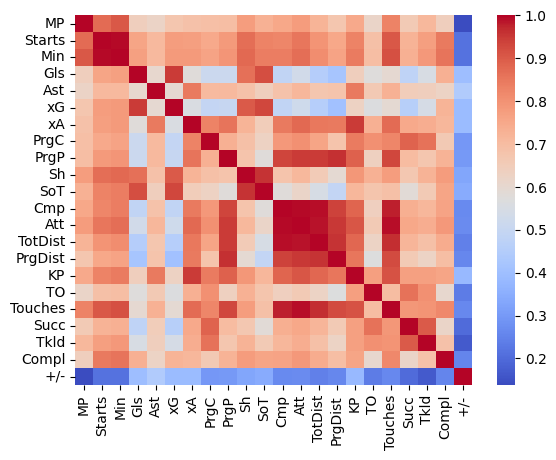

In [9]:
import seaborn as sns
sns.heatmap(fwds_num.corr(), annot = False, cmap = "coolwarm")

### Visualizations

<Axes: xlabel='TotDist', ylabel='Count'>

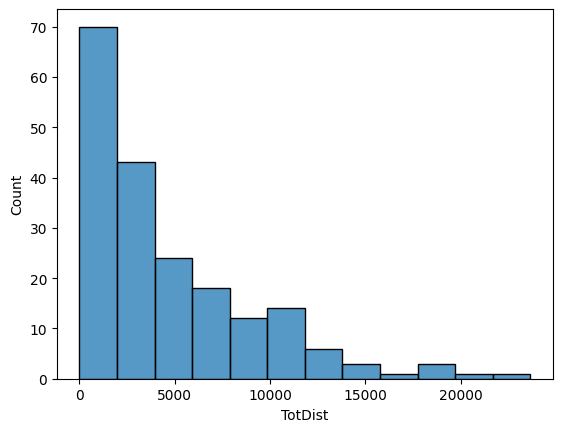

In [10]:
sns.histplot(fwds_num["TotDist"])

<Axes: xlabel='Min', ylabel='Count'>

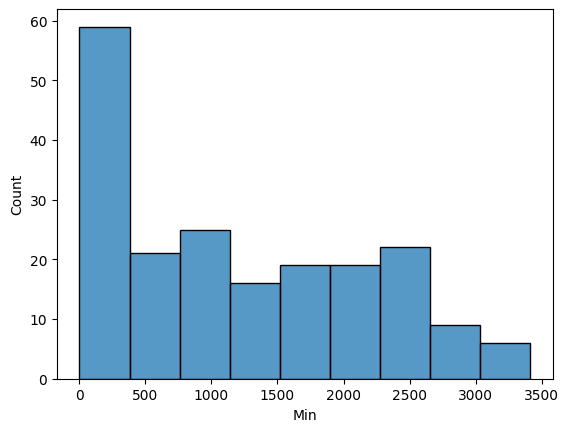

In [11]:
sns.histplot(fwds_num["Min"])

<Axes: xlabel='Gls', ylabel='Ast'>

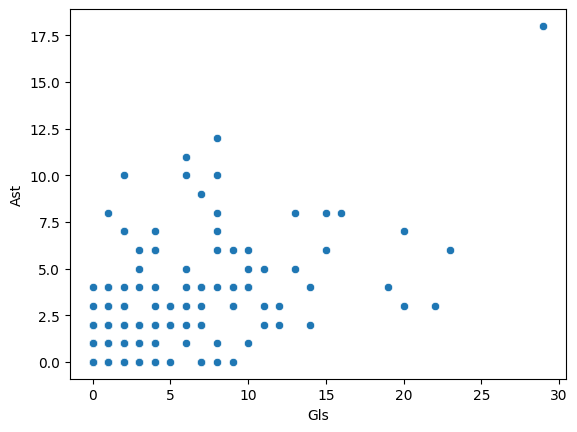

In [12]:
sns.scatterplot(fwds_num, x = "Gls", y = "Ast")

<Axes: xlabel='xG', ylabel='xA'>

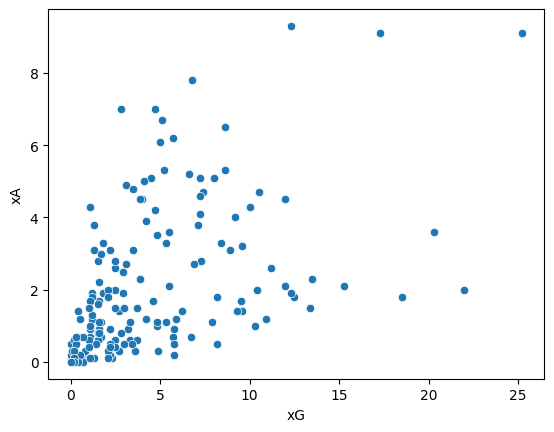

In [13]:
sns.scatterplot(fwds_num, x = "xG", y = "xA")

<Axes: xlabel='+/-', ylabel='Count'>

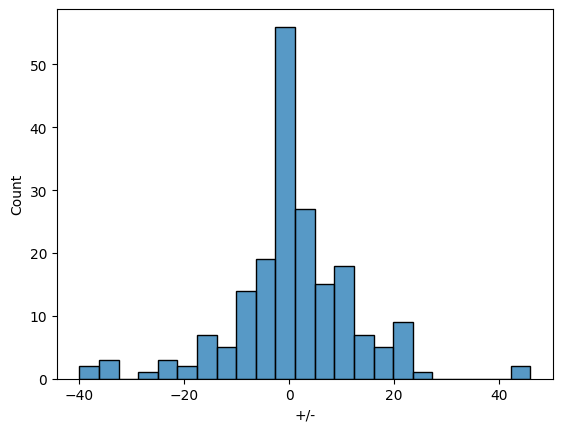

In [14]:
sns.histplot(fwds_num["+/-"])

In [15]:
fwds_agg[(fwds_agg["Gls"] > 28) & (fwds_agg["Ast"] > 17) & (fwds_agg["+/-"] > 40)]

,Player,MP,Starts,Min,Gls,Ast,xG,xA,PrgC,PrgP,...,Att,TotDist,PrgDist,KP,TO,Touches,Succ,Tkld,Compl,+/-
139,Mohamed Salah,38,38,3371,29,18,25.2,9.1,154,144,...,1263,13343,3919,88,22,1695,58,72,29,45


Player with most G/A has highest +/-. Since +/- is so hard to predict due to its wide array of factors, predicting G + A would be a great way to estimate how a forward impacts his team.

## Model

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

fwds_num["xG+xA"] = fwds_agg["xG"] + fwds_agg["xA"]

X = fwds_num.drop(["xG+xA", "xG", "xA"], axis = 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

y = fwds_num["xG+xA"]

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.2, random_state = 42)

In [25]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

ridge_model = Ridge(alpha = 1.0)
ridge_model.fit(X_train, y_train)
y_pred = ridge_model.predict(X_test)

mae = mean_squared_error(y_test, y_pred)
print(mae)
r2 = r2_score(y_test, y_pred)
print(r2)

1.817922540950656
0.9547098222817136


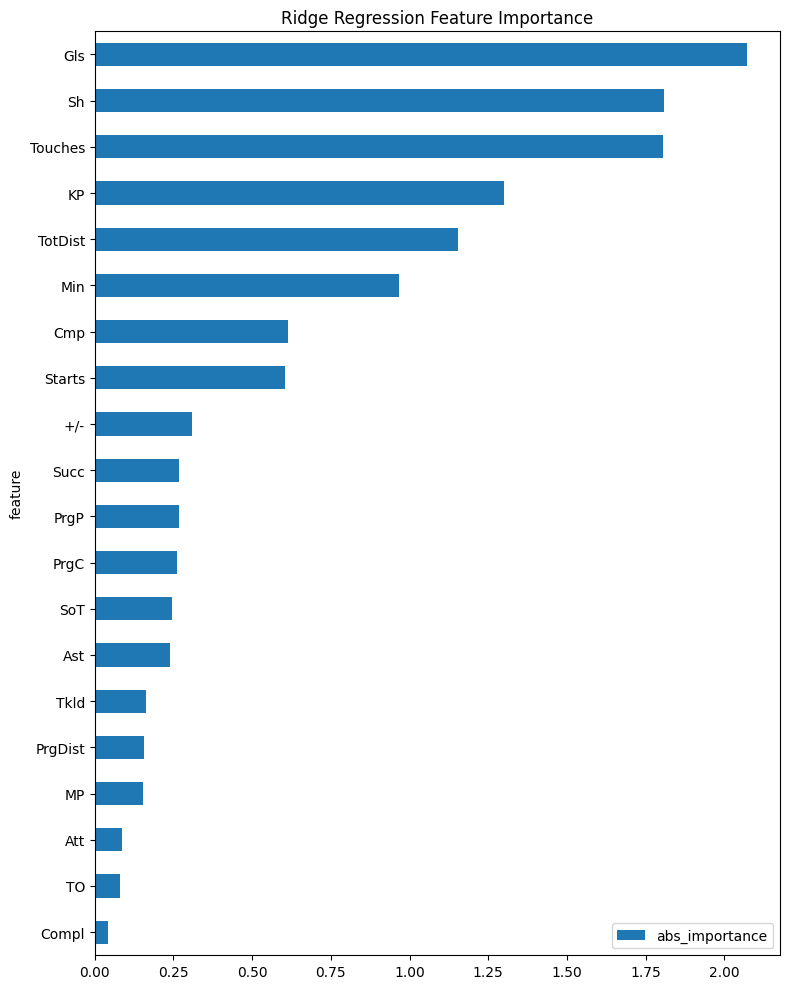

In [35]:
import matplotlib.pyplot as plt
import numpy as np

coef_importance = pd.DataFrame({
    "feature": list(X.columns),
    "coefficient": ridge_model.coef_,
    "abs_importance": np.abs(ridge_model.coef_)
}).sort_values("abs_importance", ascending = False)

coef_importance.sort_values("abs_importance").plot(
    x = "feature",
    y = "abs_importance",
    kind = "barh",
    figsize = (8, 10)
)

plt.title("Ridge Regression Feature Importance")
plt.tight_layout()
plt.show()

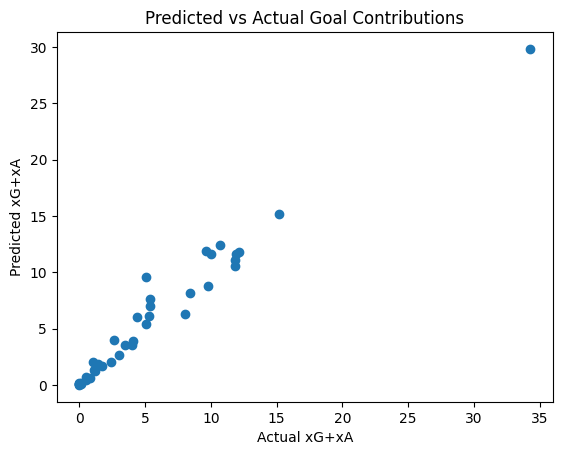

In [37]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual xG+xA")
plt.ylabel("Predicted xG+xA")
plt.title("Predicted vs Actual Goal Contributions")
plt.show()